# Laboratorio 8 – Máquinas Vectoriales de Soporte 

In [12]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')
SEED = 42

---
## 1. Mismos conjuntos de entrenamiento y prueba

Se conservan **70 % entrenamiento / 30 % prueba** con `random_state=42` y las mismas 7 variables predictoras que en todos los labs anteriores.


In [13]:
result = pyreadr.read_r('../lab7/laboratorio-7-Regresi-n-log-stica/listings.RData')
data = result['listings']
print(f'Dimensiones originales: {data.shape}')

Dimensiones originales: (171748, 80)


In [14]:
# ── Limpieza del precio ──────────────────────────────────────────────────────
data['price'] = (data['price'].astype(str)
                 .str.replace('$', '', regex=False)
                 .str.replace(',', '', regex=False))
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])
data = data[data['price'] > 0]

# ── Variable respuesta clasificación ────────────────────────────────────────
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])
print('Distribución de categorías de precio:')
print(data['price_cat'].value_counts())
print('\nRangos de precio por categoría:')
print(data.groupby('price_cat')['price'].agg(['min', 'max']))

Distribución de categorías de precio:
price_cat
barata    25689
cara      25404
media     25153
Name: count, dtype: int64

Rangos de precio por categoría:
             min      max
price_cat                
barata       8.0    143.0
media      144.0    268.0
cara       269.0  50123.0


In [15]:
FEATURES = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
            'minimum_nights', 'number_of_reviews', 'review_scores_rating']

# ── Dataset clasificación (completo) ────────────────────────────────────────
df_clf = data[FEATURES + ['price_cat']].dropna()
X_clf  = df_clf[FEATURES]
y_clf  = df_clf['price_cat']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=SEED, stratify=y_clf
)

# ── Dataset regresión (completo) ─────────────────────────────────────────────
df_reg = data[FEATURES + ['price']].dropna()
X_reg  = df_reg[FEATURES]
y_reg  = df_reg['price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=SEED
)

print(f'Clasificación (completo) → Train: {X_train_clf.shape[0]} | Test: {X_test_clf.shape[0]}')
print(f'Regresión    (completo)  → Train: {X_train_reg.shape[0]} | Test: {X_test_reg.shape[0]}')

# ── Sub-muestras ESTRATIFICADAS para SVM (10 000 filas) ─────────────────────

SVM_SAMPLE = 10_000

X_svm_tr, _, y_svm_tr, _ = train_test_split(
    X_train_clf, y_train_clf,
    train_size=SVM_SAMPLE, random_state=SEED, stratify=y_train_clf
)
X_svr_tr, _, y_svr_tr, _ = train_test_split(
    X_train_reg, y_train_reg,
    train_size=SVM_SAMPLE, random_state=SEED
)

print(f'\nSub-muestra SVM  → {X_svm_tr.shape[0]} filas  |  Test completo: {X_test_clf.shape[0]}')
print(f'Sub-muestra SVR  → {X_svr_tr.shape[0]} filas  |  Test completo: {X_test_reg.shape[0]}')

Clasificación (completo) → Train: 43905 | Test: 18817
Regresión    (completo)  → Train: 43905 | Test: 18817

Sub-muestra SVM  → 10000 filas  |  Test completo: 18817
Sub-muestra SVR  → 10000 filas  |  Test completo: 18817


---
## 2. Exploración de datos y transformaciones para SVM

Las SVM calculan distancias en el espacio de características, por lo que variables con escalas muy distintas (ej. `number_of_reviews` puede superar 1000 vs. `review_scores_rating` de 0–5) distorsionan el hiperplano. **La estandarización es obligatoria**.

In [16]:
print('Estadísticas descriptivas – sub-muestra SVM train:')
X_svm_tr.describe().round(2)

Estadísticas descriptivas – sub-muestra SVM train:


,accommodates,bathrooms,minimum_nights,number_of_reviews,review_scores_rating
count,10000.00,10000.00,10000.0,10000.00,10000.00
mean,4.84,1.59,7.4,64.28,4.80
std,2.95,0.90,16.3,99.45,0.32
min,1.00,0.00,1.0,1.00,1.00
25%,2.00,1.00,1.0,6.00,4.75
50%,4.00,1.00,2.0,26.00,4.89
75%,6.00,2.00,4.0,80.00,5.00
max,16.00,11.50,364.0,1291.00,5.00


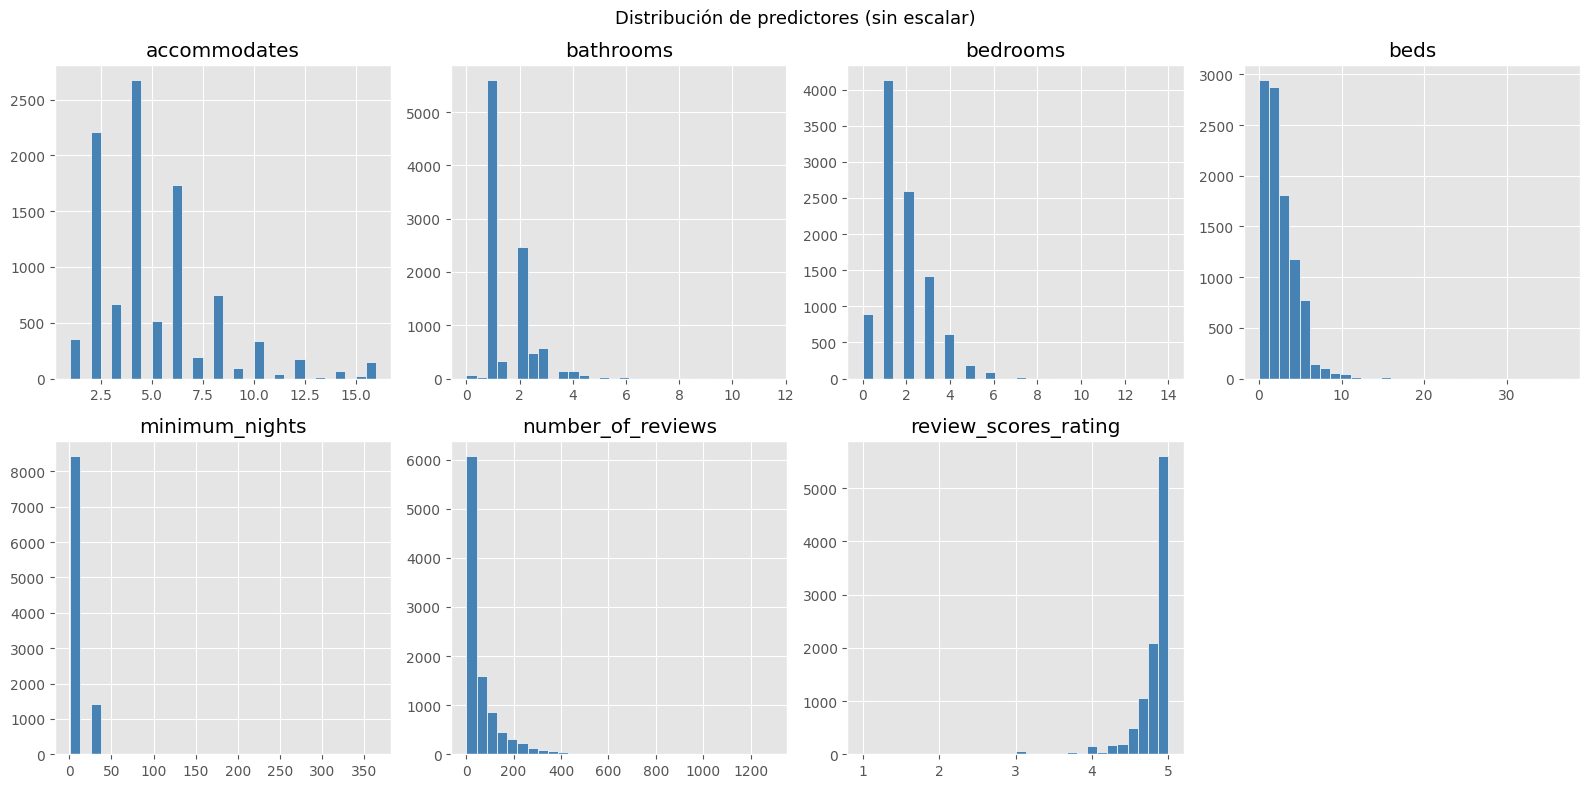

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    axes[i].hist(X_svm_tr[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Distribución de predictores (sin escalar)', fontsize=13)
plt.tight_layout(); plt.show()

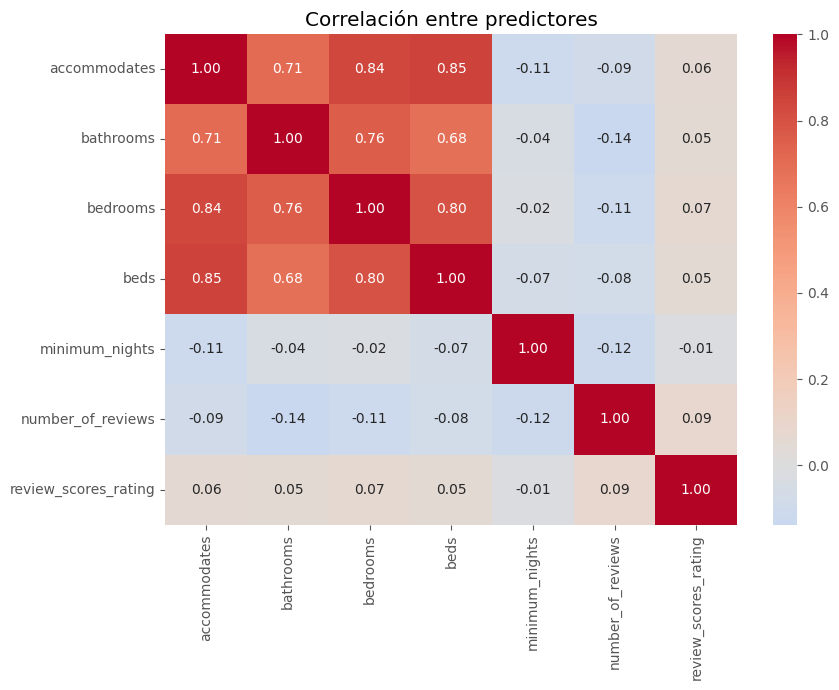


Transformaciones necesarias para SVM:
 1. Estandarización (StandardScaler): media=0, std=1 por columna.
    El scaler se ajusta SOLO sobre la sub-muestra de entrenamiento
    y se aplica al conjunto de prueba completo (evita data leakage).
 2. Todas las variables ya son numéricas → no se requiere one-hot encoding.
 3. Muestreo estratificado de 10 000 filas para SVM/SVR por limitación
    computacional (SVM es O(n²–n³)); los demás algoritmos usan el set completo.



In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(X_svm_tr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre predictores')
plt.tight_layout(); plt.show()

print("""
Transformaciones necesarias para SVM:
 1. Estandarización (StandardScaler): media=0, std=1 por columna.
    El scaler se ajusta SOLO sobre la sub-muestra de entrenamiento
    y se aplica al conjunto de prueba completo (evita data leakage).
 2. Todas las variables ya son numéricas → no se requiere one-hot encoding.
 3. Muestreo estratificado de 10 000 filas para SVM/SVR por limitación
    computacional (SVM es O(n²–n³)); los demás algoritmos usan el set completo.
""")

In [19]:
# Escalado – clasificación
# Ajuste sobre sub-muestra SVM
scaler_clf = StandardScaler()
X_svm_tr_sc    = scaler_clf.fit_transform(X_svm_tr)
X_test_clf_sc  = scaler_clf.transform(X_test_clf)
X_train_clf_sc = scaler_clf.transform(X_train_clf)

# Escalado – regresión
scaler_reg = StandardScaler()
X_svr_tr_sc    = scaler_reg.fit_transform(X_svr_tr)
X_test_reg_sc  = scaler_reg.transform(X_test_reg)
X_train_reg_sc = scaler_reg.transform(X_train_reg)

print('Escalado completado.')
print('Media sub-muestra SVM (debe ser ~0):', X_svm_tr_sc.mean(axis=0).round(3))

Escalado completado.
Media sub-muestra SVM (debe ser ~0): [-0.  0.  0.  0.  0. -0.  0.]


---
## 3. Variable respuesta: price_cat (barata / media / cara)

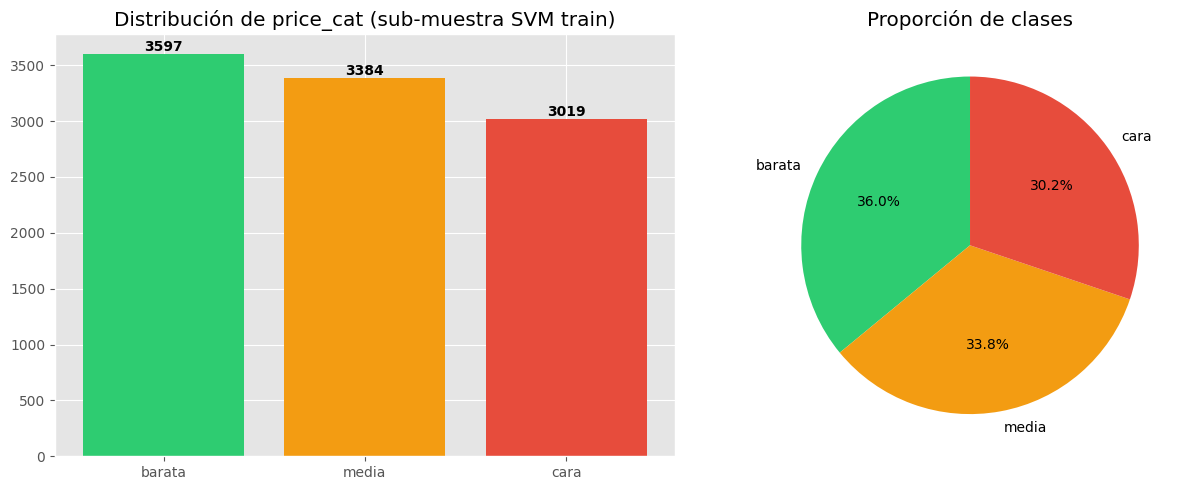

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = y_svm_tr.value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#f39c12','#e74c3c'])
axes[0].set_title('Distribución de price_cat (sub-muestra SVM train)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index,
            colors=['#2ecc71','#f39c12','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')
plt.tight_layout(); plt.show()

---
## 4. Modelos SVM con diferentes kernels y parámetros

| Modelo | Implementación | C | Gamma / d |
|--------|---------------|---|-----------|
| SVM1 | `LinearSVC` | 1.0 | — |
| SVM2 | `SVC(rbf)` | 1.0 | scale |
| SVM3 | `SVC(rbf)` | 10.0 | 0.1 |
| SVM4 | `SVC(poly, d=3)` | 1.0 | scale |
| SVM5 | `SVC(rbf)` + GridSearch | auto | auto |

C: penalización por error. Alto → margen estrecho → riesgo de sobreajuste.  
gamma: radio de influencia de cada punto. `scale` = 1/(n_features × var(X)).  
d: grado del polinomio.

In [21]:
modelos_clf   = {}
tiempos_clf   = {}
acc_train_clf = {}
acc_test_clf  = {}

# ── SVM1: LinearSVC ──────────────
print('Entrenando SVM1_lineal (LinearSVC)...', end=' ')
lsvc = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=SEED))
t0 = time.time()
lsvc.fit(X_svm_tr_sc, y_svm_tr)
elapsed = round(time.time() - t0, 2)
modelos_clf['SVM1_lineal'] = lsvc
tiempos_clf['SVM1_lineal'] = elapsed
acc_train_clf['SVM1_lineal'] = round(accuracy_score(y_svm_tr, lsvc.predict(X_svm_tr_sc)), 4)
acc_test_clf['SVM1_lineal']  = round(accuracy_score(y_test_clf, lsvc.predict(X_test_clf_sc)), 4)
print(f'OK ({elapsed}s) | train={acc_train_clf["SVM1_lineal"]} test={acc_test_clf["SVM1_lineal"]}')

# ── SVM2–4: SVC con kernel RBF y polinomial ──────────────────────────────────
configs = {
    'SVM2_rbf_C1'  : dict(kernel='rbf',  C=1.0,  gamma='scale'),
    'SVM3_rbf_C10' : dict(kernel='rbf',  C=10.0, gamma=0.1),
    'SVM4_poly_d3' : dict(kernel='poly', C=1.0,  gamma='scale', degree=3),
}
for nombre, params in configs.items():
    print(f'Entrenando {nombre}...', end=' ')
    svm = SVC(**params, random_state=SEED, probability=True)
    t0 = time.time()
    svm.fit(X_svm_tr_sc, y_svm_tr)
    elapsed = round(time.time() - t0, 2)
    modelos_clf[nombre]   = svm
    tiempos_clf[nombre]   = elapsed
    acc_train_clf[nombre] = round(accuracy_score(y_svm_tr,   svm.predict(X_svm_tr_sc)),   4)
    acc_test_clf[nombre]  = round(accuracy_score(y_test_clf, svm.predict(X_test_clf_sc)), 4)
    print(f'OK ({elapsed}s) | train={acc_train_clf[nombre]} test={acc_test_clf[nombre]}')

Entrenando SVM1_lineal (LinearSVC)... OK (0.54s) | train=0.5824 test=0.5732
Entrenando SVM2_rbf_C1... OK (11.04s) | train=0.608 test=0.5928
Entrenando SVM3_rbf_C10... OK (14.14s) | train=0.6131 test=0.5894
Entrenando SVM4_poly_d3... OK (15.59s) | train=0.5595 test=0.5493


In [22]:
# ── SVM5: GridSearchCV ──────────────────
print('Entrenando SVM5 (GridSearchCV, grid reducido, cv=3)...')
param_grid_clf = {
    'C'    : [1.0, 10.0],
    'gamma': ['scale', 0.1]
}
gs_clf = GridSearchCV(
    SVC(kernel='rbf', random_state=SEED, probability=True),
    param_grid=param_grid_clf, cv=3,
    scoring='accuracy', n_jobs=-1, verbose=1
)
t0 = time.time()
gs_clf.fit(X_svm_tr_sc, y_svm_tr)
gs_time = round(time.time() - t0, 2)

nombre_gs = 'SVM5_rbf_GS'
modelos_clf[nombre_gs]   = gs_clf.best_estimator_
tiempos_clf[nombre_gs]   = gs_time
acc_train_clf[nombre_gs] = round(accuracy_score(y_svm_tr,   gs_clf.best_estimator_.predict(X_svm_tr_sc)),   4)
acc_test_clf[nombre_gs]  = round(accuracy_score(y_test_clf, gs_clf.best_estimator_.predict(X_test_clf_sc)), 4)

print(f'Mejores params: {gs_clf.best_params_}  |  CV acc: {gs_clf.best_score_:.4f}')
print(f'SVM5: train={acc_train_clf[nombre_gs]}  test={acc_test_clf[nombre_gs]}  tiempo={gs_time}s')

Entrenando SVM5 (GridSearchCV, grid reducido, cv=3)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores params: {'C': 10.0, 'gamma': 'scale'}  |  CV acc: 0.5980
SVM5: train=0.6218  test=0.591  tiempo=53.85s


---
## 5. Predicciones con cada modelo

In [23]:
preds_clf = {nombre: modelo.predict(X_test_clf_sc)
             for nombre, modelo in modelos_clf.items()}

sample = pd.DataFrame({'Real': y_test_clf.values[:20]})
for nombre, preds in preds_clf.items():
    sample[nombre] = preds[:20]
print('Muestra de predicciones vs valores reales (primeras 20 filas):')
print(sample.to_string(index=False))

Muestra de predicciones vs valores reales (primeras 20 filas):
  Real SVM1_lineal SVM2_rbf_C1 SVM3_rbf_C10 SVM4_poly_d3 SVM5_rbf_GS
barata      barata      barata       barata       barata      barata
 media        cara        cara         cara        media        cara
 media      barata      barata       barata       barata      barata
 media       media        cara         cara        media        cara
 media      barata      barata       barata       barata      barata
  cara      barata      barata       barata       barata      barata
barata      barata      barata       barata       barata      barata
barata       media       media        media        media       media
 media      barata      barata       barata       barata      barata
barata      barata      barata       barata       barata      barata
 media        cara        cara         cara         cara        cara
  cara        cara       media        media        media       media
barata      barata      barata       bar

---
## 6. Matrices de confusión

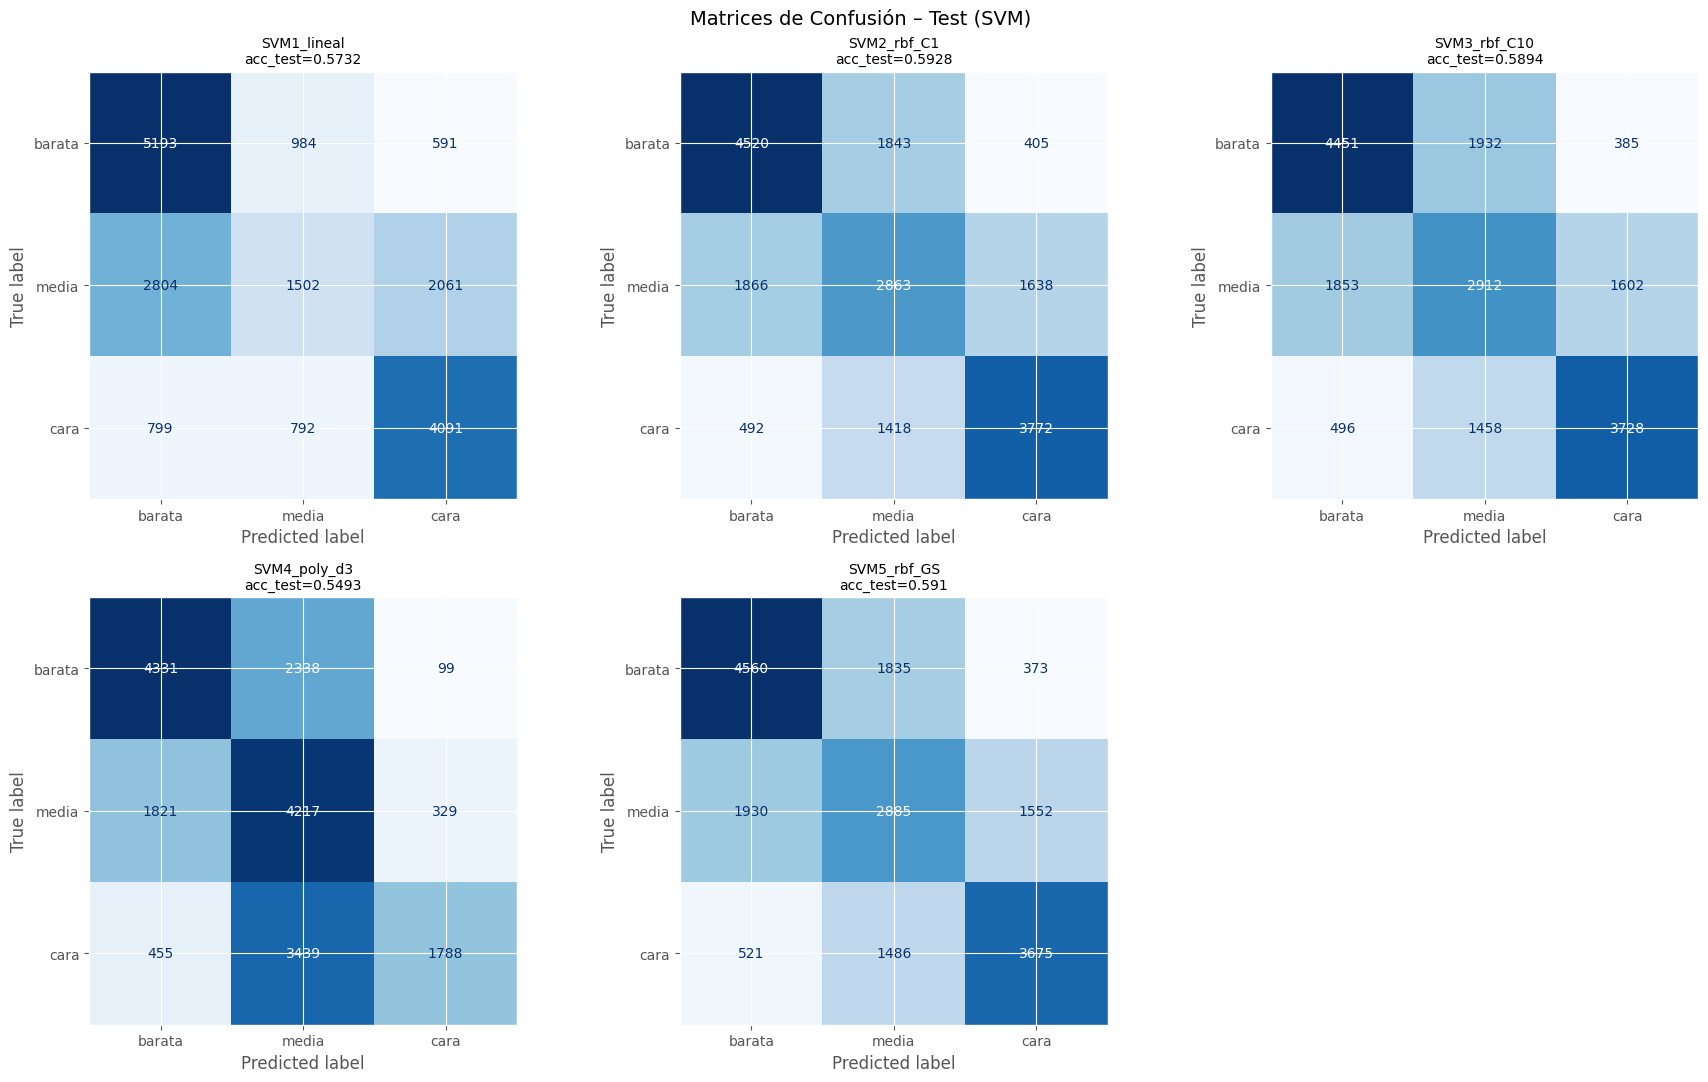

In [24]:
clases = ['barata', 'media', 'cara']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, (nombre, preds) in enumerate(preds_clf.items()):
    cm = confusion_matrix(y_test_clf, preds, labels=clases)
    ConfusionMatrixDisplay(cm, display_labels=clases).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{nombre}\nacc_test={acc_test_clf[nombre]}', fontsize=10)
axes[-1].set_visible(False)
plt.suptitle('Matrices de Confusión – Test (SVM)', fontsize=14)
plt.tight_layout(); plt.show()

In [26]:
for nombre, preds in preds_clf.items():
    print('=' * 55)
    print(f'  {nombre}')
    print('=' * 55)
    print(classification_report(y_test_clf, preds, target_names=clases))

  SVM1_lineal
              precision    recall  f1-score   support

      barata       0.59      0.77      0.67      6768
       media       0.61      0.72      0.66      5682
        cara       0.46      0.24      0.31      6367

    accuracy                           0.57     18817
   macro avg       0.55      0.57      0.55     18817
weighted avg       0.55      0.57      0.54     18817

  SVM2_rbf_C1
              precision    recall  f1-score   support

      barata       0.66      0.67      0.66      6768
       media       0.65      0.66      0.66      5682
        cara       0.47      0.45      0.46      6367

    accuracy                           0.59     18817
   macro avg       0.59      0.59      0.59     18817
weighted avg       0.59      0.59      0.59     18817

  SVM3_rbf_C10
              precision    recall  f1-score   support

      barata       0.65      0.66      0.66      6768
       media       0.65      0.66      0.65      5682
        cara       0.46      0.4

---
## 7. Análisis de sobreajuste y desajuste

      Modelo  Acc_Train  Acc_Test  Brecha Diagnóstico
 SVM1_lineal     0.5824    0.5732  0.0092 Buen ajuste
 SVM2_rbf_C1     0.6080    0.5928  0.0152 Buen ajuste
SVM3_rbf_C10     0.6131    0.5894  0.0237 Buen ajuste
SVM4_poly_d3     0.5595    0.5493  0.0102 Buen ajuste
 SVM5_rbf_GS     0.6218    0.5910  0.0308 Buen ajuste


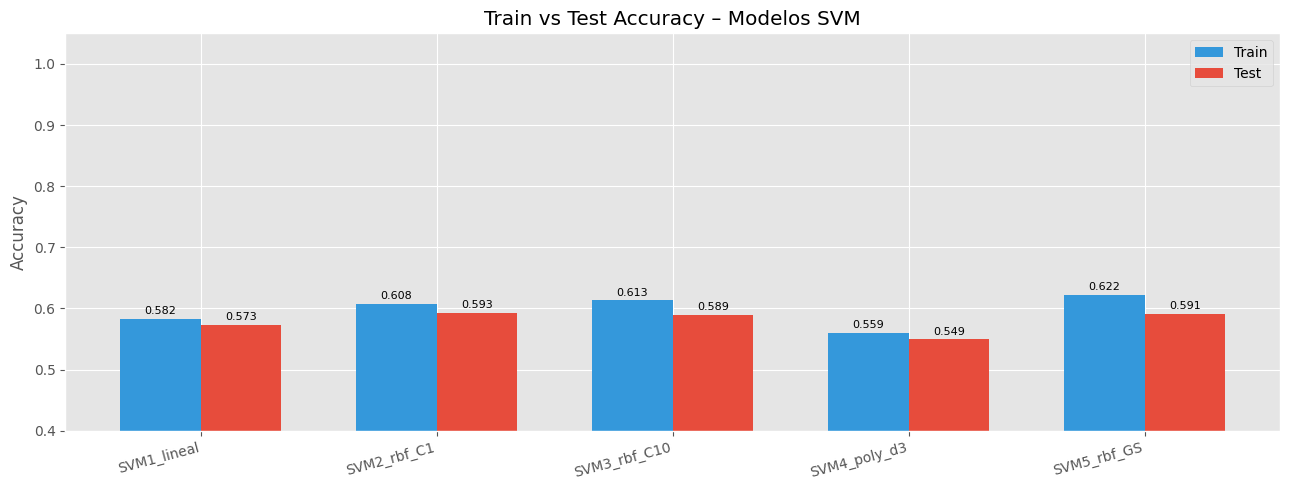


Estrategias ante sobreajuste en SVM:
  • Reducir C (margen más amplio / más regularización).
  • Reducir gamma (frontera de decisión más suave).
  • Usar validación cruzada para seleccionar hiperparámetros.

Estrategias ante desajuste:
  • Aumentar C o cambiar a kernel más expresivo (RBF, poly).
  • Agregar más variables predictoras o transformaciones.



In [27]:
def diagnostico_clf(brecha, acc):
    if brecha > 0.05: return 'Sobreajuste'
    if acc < 0.50:    return 'Desajuste'
    return 'Buen ajuste'

nombres_svm = list(acc_train_clf.keys())
rows = []
for n in nombres_svm:
    brecha = round(acc_train_clf[n] - acc_test_clf[n], 4)
    rows.append({'Modelo': n, 'Acc_Train': acc_train_clf[n],
                 'Acc_Test': acc_test_clf[n], 'Brecha': brecha,
                 'Diagnóstico': diagnostico_clf(brecha, acc_test_clf[n])})
df_diag = pd.DataFrame(rows)
print(df_diag.to_string(index=False))

# Gráfico barras train vs test
x = np.arange(len(nombres_svm))
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - 0.17, [acc_train_clf[n] for n in nombres_svm], 0.34, label='Train', color='#3498db')
b2 = ax.bar(x + 0.17, [acc_test_clf[n]  for n in nombres_svm], 0.34, label='Test',  color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(nombres_svm, rotation=15, ha='right')
ax.set_ylim(0.4, 1.05); ax.set_ylabel('Accuracy'); ax.legend()
ax.set_title('Train vs Test Accuracy – Modelos SVM')
ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout(); plt.show()

print("""
Estrategias ante sobreajuste en SVM:
  • Reducir C (margen más amplio / más regularización).
  • Reducir gamma (frontera de decisión más suave).
  • Usar validación cruzada para seleccionar hiperparámetros.

Estrategias ante desajuste:
  • Aumentar C o cambiar a kernel más expresivo (RBF, poly).
  • Agregar más variables predictoras o transformaciones.
""")

---
## 8. Comparación entre modelos SVM: efectividad, tiempo y errores

In [28]:
resumen_svm = []
for nombre, preds in preds_clf.items():
    cm = confusion_matrix(y_test_clf, preds, labels=clases)
    err = {c: int(cm[i].sum() - cm[i, i]) for i, c in enumerate(clases)}
    resumen_svm.append({
        'Modelo'    : nombre,
        'Acc_Train' : acc_train_clf[nombre],
        'Acc_Test'  : acc_test_clf[nombre],
        'F1_macro'  : round(f1_score(y_test_clf, preds, average='macro'), 4),
        'Prec_mac'  : round(precision_score(y_test_clf, preds, average='macro'), 4),
        'Rec_mac'   : round(recall_score(y_test_clf, preds, average='macro'), 4),
        'Err_barata': err['barata'],
        'Err_media' : err['media'],
        'Err_cara'  : err['cara'],
        'Tiempo_s'  : tiempos_clf[nombre],
    })

df_svm = pd.DataFrame(resumen_svm)
print('=== Resumen comparativo modelos SVM ===')
print(df_svm.to_string(index=False))

=== Resumen comparativo modelos SVM ===
      Modelo  Acc_Train  Acc_Test  F1_macro  Prec_mac  Rec_mac  Err_barata  Err_media  Err_cara  Tiempo_s
 SVM1_lineal     0.5824    0.5732    0.5458    0.5518   0.5744        1575       4865      1591      0.54
 SVM2_rbf_C1     0.6080    0.5928    0.5923    0.5911   0.5938        2248       3504      1910     11.04
SVM3_rbf_C10     0.6131    0.5894    0.5900    0.5897   0.5904        2317       3455      1954     14.14
SVM4_poly_d3     0.5595    0.5493    0.5386    0.6281   0.5390        2437       2150      3894     15.59
 SVM5_rbf_GS     0.6218    0.5910    0.5908    0.5905   0.5912        2208       3482      2007     53.85


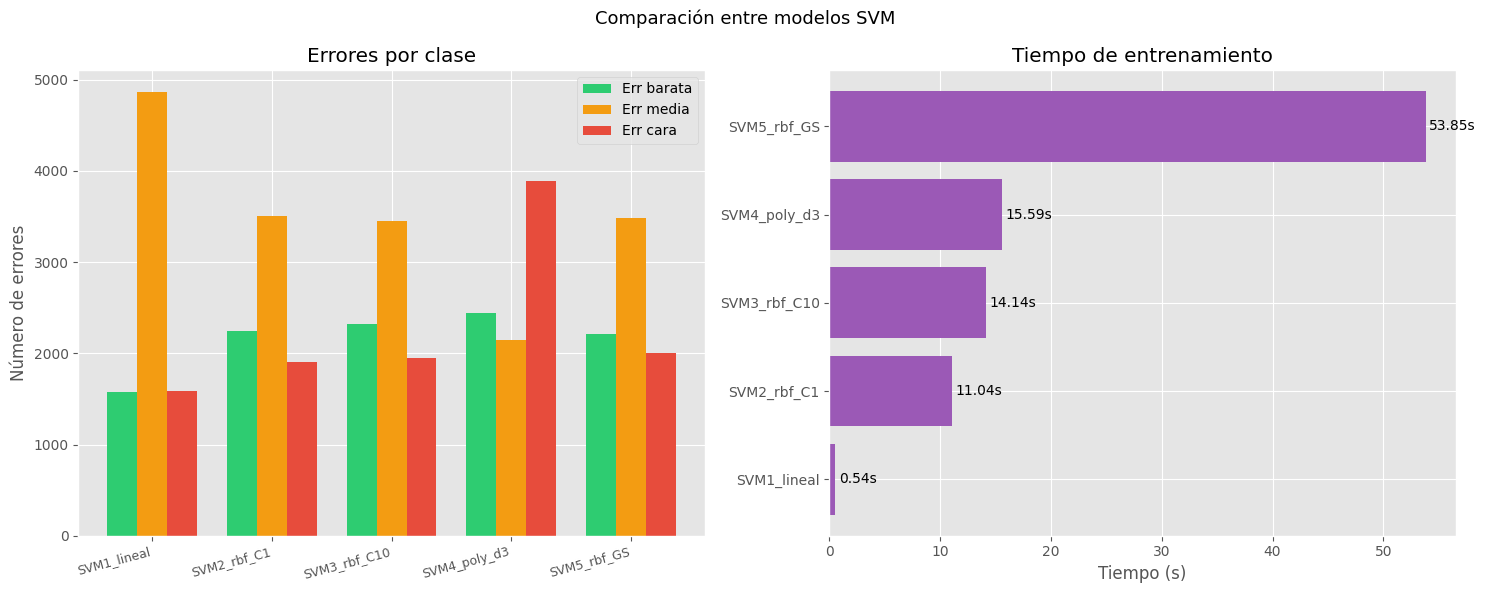

Mejor SVM (F1 macro): SVM2_rbf_C1
Clase con más errores:  media (17456)
Clase con menos errores:barata (10785)
Modelo más rápido: SVM1_lineal


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x_pos = np.arange(len(df_svm)); w = 0.25
axes[0].bar(x_pos - w, df_svm['Err_barata'], w, label='Err barata', color='#2ecc71')
axes[0].bar(x_pos,     df_svm['Err_media'],  w, label='Err media',  color='#f39c12')
axes[0].bar(x_pos + w, df_svm['Err_cara'],   w, label='Err cara',   color='#e74c3c')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(df_svm['Modelo'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Número de errores'); axes[0].set_title('Errores por clase'); axes[0].legend()

axes[1].barh(df_svm['Modelo'], df_svm['Tiempo_s'], color='#9b59b6')
axes[1].set_xlabel('Tiempo (s)'); axes[1].set_title('Tiempo de entrenamiento')
for i, v in enumerate(df_svm['Tiempo_s']):
    axes[1].text(v + 0.3, i, f'{v}s', va='center')

plt.suptitle('Comparación entre modelos SVM', fontsize=13)
plt.tight_layout(); plt.show()

mejor_svm = df_svm.loc[df_svm['F1_macro'].idxmax(), 'Modelo']
clase_err  = df_svm[['Err_barata','Err_media','Err_cara']].sum()
print(f'Mejor SVM (F1 macro): {mejor_svm}')
print(f'Clase con más errores:  {clase_err.idxmax().replace("Err_","")} ({int(clase_err.max())})')
print(f'Clase con menos errores:{clase_err.idxmin().replace("Err_","")} ({int(clase_err.min())})')
print(f'Modelo más rápido: {df_svm.loc[df_svm["Tiempo_s"].idxmin(),"Modelo"]}')

---
## 9. Comparación del mejor SVM con clasificadores de labs anteriores

Los modelos de labs anteriores se entrenan con el **conjunto de entrenamiento completo** (misma partición). Esto es válido para la comparación porque son algoritmos que escalan bien y usan los mismos datos de prueba.

In [30]:
clf_anteriores = {
    'Arbol_Dec'    : (DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=SEED),
                      X_train_clf.values, X_test_clf.values),
    'Random_Forest': (RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
                      X_train_clf.values, X_test_clf.values),
    'Naive_Bayes'  : (GaussianNB(),
                      X_train_clf.values, X_test_clf.values),
    'KNN_k5'       : (KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                      X_train_clf_sc, X_test_clf_sc),
    'Reg_Logist'   : (LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED),
                      X_train_clf_sc, X_test_clf_sc),
}

resultados_comp = []
for nombre, (modelo, X_tr, X_te) in clf_anteriores.items():
    t0 = time.time()
    modelo.fit(X_tr, y_train_clf)
    elapsed = round(time.time() - t0, 2)
    preds = modelo.predict(X_te)
    acc_tr = round(accuracy_score(y_train_clf, modelo.predict(X_tr)), 4)
    acc_te = round(accuracy_score(y_test_clf, preds), 4)
    resultados_comp.append({
        'Modelo'    : nombre,
        'Acc_Train' : acc_tr,
        'Acc_Test'  : acc_te,
        'F1_macro'  : round(f1_score(y_test_clf, preds, average='macro'), 4),
        'Prec_mac'  : round(precision_score(y_test_clf, preds, average='macro'), 4),
        'Rec_mac'   : round(recall_score(y_test_clf, preds, average='macro'), 4),
        'Tiempo_s'  : elapsed,
    })
    print(f'{nombre}: acc_train={acc_tr}  acc_test={acc_te}  tiempo={elapsed}s')

# Agregar el mejor SVM
mejor_svm_nombre = df_svm.loc[df_svm['F1_macro'].idxmax(), 'Modelo']
resultados_comp.append({
    'Modelo'    : f'SVM_best ({mejor_svm_nombre})',
    'Acc_Train' : acc_train_clf[mejor_svm_nombre],
    'Acc_Test'  : acc_test_clf[mejor_svm_nombre],
    'F1_macro'  : round(f1_score(y_test_clf, preds_clf[mejor_svm_nombre], average='macro'), 4),
    'Prec_mac'  : round(precision_score(y_test_clf, preds_clf[mejor_svm_nombre], average='macro'), 4),
    'Rec_mac'   : round(recall_score(y_test_clf, preds_clf[mejor_svm_nombre], average='macro'), 4),
    'Tiempo_s'  : tiempos_clf[mejor_svm_nombre],
})

df_comp = pd.DataFrame(resultados_comp).sort_values('F1_macro', ascending=False)
print('\n=== Comparación – todos los algoritmos de clasificación ===')
print(df_comp.to_string(index=False))

Arbol_Dec: acc_train=0.5827  acc_test=0.5758  tiempo=0.05s
Random_Forest: acc_train=0.9316  acc_test=0.5771  tiempo=0.83s
Naive_Bayes: acc_train=0.5593  acc_test=0.5525  tiempo=0.05s
KNN_k5: acc_train=0.6961  acc_test=0.5652  tiempo=0.07s
Reg_Logist: acc_train=0.5943  acc_test=0.5868  tiempo=0.1s

=== Comparación – todos los algoritmos de clasificación ===
                Modelo  Acc_Train  Acc_Test  F1_macro  Prec_mac  Rec_mac  Tiempo_s
SVM_best (SVM2_rbf_C1)     0.6080    0.5928    0.5923    0.5911   0.5938     11.04
            Reg_Logist     0.5943    0.5868    0.5804    0.5786   0.5868      0.10
         Random_Forest     0.9316    0.5771    0.5767    0.5764   0.5772      0.83
             Arbol_Dec     0.5827    0.5758    0.5717    0.5705   0.5807      0.05
                KNN_k5     0.6961    0.5652    0.5581    0.5574   0.5647      0.07
           Naive_Bayes     0.5593    0.5525    0.5374    0.5639   0.5444      0.05


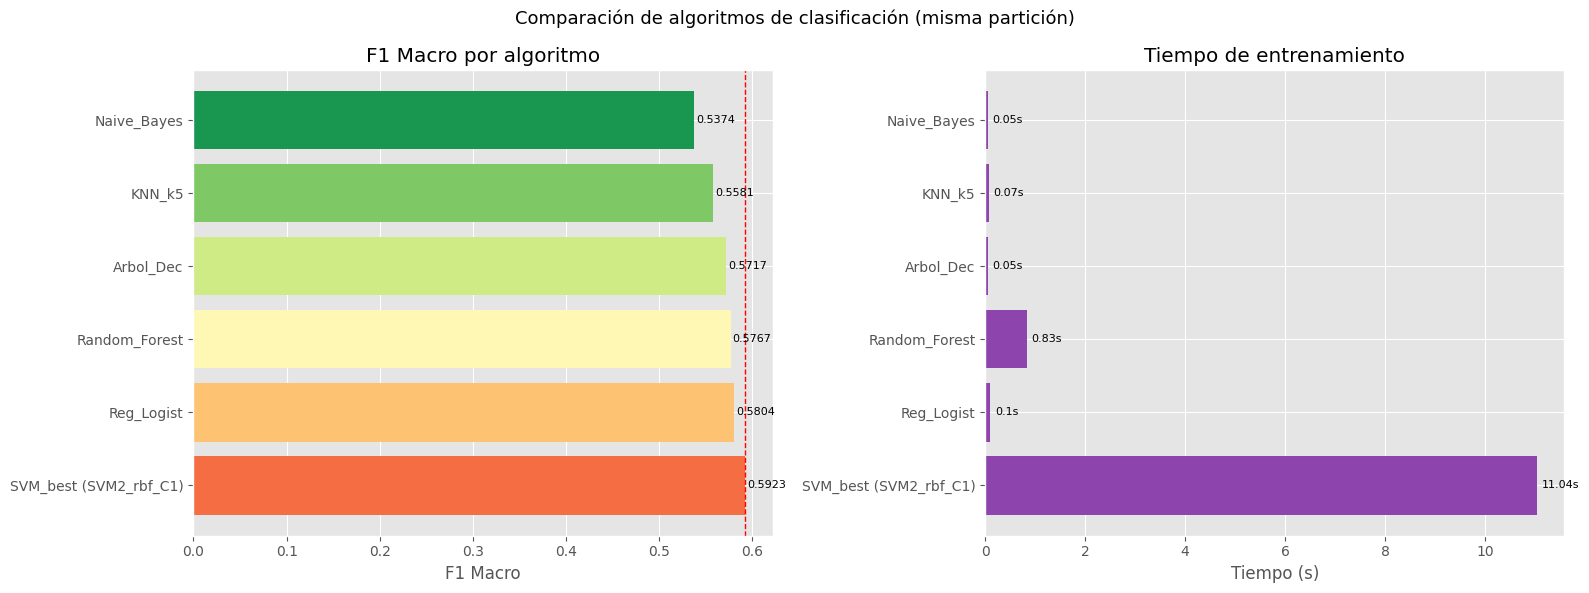

Mejor clasificador (F1 macro): SVM_best (SVM2_rbf_C1)
Más rápido: Arbol_Dec


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_comp)))
axes[0].barh(df_comp['Modelo'], df_comp['F1_macro'], color=colors_bar)
axes[0].set_xlabel('F1 Macro'); axes[0].set_title('F1 Macro por algoritmo')
axes[0].axvline(df_comp['F1_macro'].max(), color='red', linestyle='--', lw=1)
for i, v in enumerate(df_comp['F1_macro']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

axes[1].barh(df_comp['Modelo'], df_comp['Tiempo_s'], color='#8e44ad')
axes[1].set_xlabel('Tiempo (s)'); axes[1].set_title('Tiempo de entrenamiento')
for i, v in enumerate(df_comp['Tiempo_s']):
    axes[1].text(v + 0.1, i, f'{v}s', va='center', fontsize=8)

plt.suptitle('Comparación de algoritmos de clasificación (misma partición)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Mejor clasificador (F1 macro): {df_comp.iloc[0]["Modelo"]}')
print(f'Más rápido: {df_comp.loc[df_comp["Tiempo_s"].idxmin(),"Modelo"]}')

---
## 10. Tabla de sobreajuste — todos los algoritmos de clasificación

=== Tabla de sobreajuste – clasificación ===
                Modelo  Acc_Train  Acc_Test  Brecha Diagnóstico
         Random_Forest     0.9316    0.5771  0.3545 Sobreajuste
                KNN_k5     0.6961    0.5652  0.1309 Sobreajuste
SVM_best (SVM2_rbf_C1)     0.6080    0.5928  0.0152 Buen ajuste
            Reg_Logist     0.5943    0.5868  0.0075 Buen ajuste
             Arbol_Dec     0.5827    0.5758  0.0069 Buen ajuste
           Naive_Bayes     0.5593    0.5525  0.0068 Buen ajuste


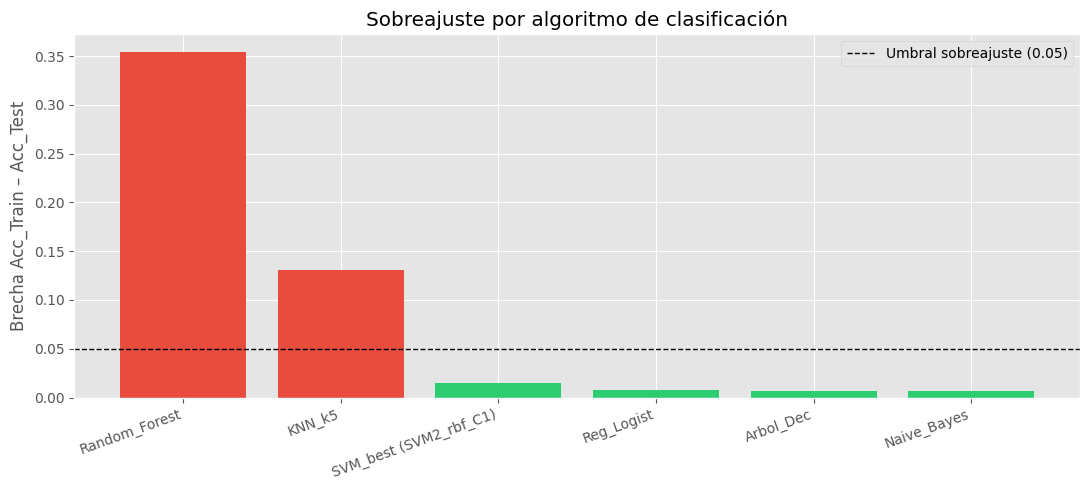


Métricas para detectar sobreajuste en clasificación:
  1. Brecha Acc_Train – Acc_Test > 0.05 → sobreajuste.
  2. F1-macro en train vs test (caída significativa → sobreajuste).
  3. Alta varianza en validación cruzada (std alto entre folds).



In [32]:
df_overfit = df_comp[['Modelo','Acc_Train','Acc_Test']].copy()
df_overfit['Brecha'] = (df_overfit['Acc_Train'] - df_overfit['Acc_Test']).round(4)
df_overfit['Diagnóstico'] = df_overfit.apply(
    lambda r: diagnostico_clf(r['Brecha'], r['Acc_Test']), axis=1
)
df_overfit = df_overfit.sort_values('Brecha', ascending=False)

print('=== Tabla de sobreajuste – clasificación ===')
print(df_overfit.to_string(index=False))

colors_bar = ['#e74c3c' if b > 0.05 else '#2ecc71' for b in df_overfit['Brecha']]
plt.figure(figsize=(11, 5))
plt.bar(df_overfit['Modelo'], df_overfit['Brecha'], color=colors_bar)
plt.axhline(0.05, color='black', linestyle='--', lw=1, label='Umbral sobreajuste (0.05)')
plt.xticks(rotation=20, ha='right'); plt.ylabel('Brecha Acc_Train – Acc_Test')
plt.title('Sobreajuste por algoritmo de clasificación'); plt.legend()
plt.tight_layout(); plt.show()

print("""
Métricas para detectar sobreajuste en clasificación:
  1. Brecha Acc_Train – Acc_Test > 0.05 → sobreajuste.
  2. F1-macro en train vs test (caída significativa → sobreajuste).
  3. Alta varianza en validación cruzada (std alto entre folds).
""")

---
## 11. Modelo SVR — Regresión del precio de la propiedad

Se predice `price` directamente (variable numérica continua). Se usa la sub-muestra de 10 000 filas por la misma razón de escala que en SVM. El conjunto de prueba es el completo para evaluación justa.

In [33]:
modelos_svr    = {}
tiempos_svr    = {}
rmse_train_svr = {}
rmse_test_svr  = {}
r2_train_svr   = {}
r2_test_svr    = {}

# ── SVR1: LinearSVR  ──────────────
print('Entrenando SVR1_lineal (LinearSVR)...', end=' ')
lsvr = LinearSVR(C=1.0, max_iter=5000)
t0 = time.time()
lsvr.fit(X_svr_tr_sc, y_svr_tr)
elapsed = round(time.time() - t0, 2)
modelos_svr['SVR1_lineal']    = lsvr
tiempos_svr['SVR1_lineal']    = elapsed
rmse_train_svr['SVR1_lineal'] = round(np.sqrt(mean_squared_error(y_svr_tr,   lsvr.predict(X_svr_tr_sc))),  4)
rmse_test_svr['SVR1_lineal']  = round(np.sqrt(mean_squared_error(y_test_reg, lsvr.predict(X_test_reg_sc))), 4)
r2_train_svr['SVR1_lineal']   = round(r2_score(y_svr_tr,   lsvr.predict(X_svr_tr_sc)),  4)
r2_test_svr['SVR1_lineal']    = round(r2_score(y_test_reg, lsvr.predict(X_test_reg_sc)), 4)
print(f'OK ({elapsed}s) | RMSE_test={rmse_test_svr["SVR1_lineal"]}  R²={r2_test_svr["SVR1_lineal"]}')

# ── SVR2–4: SVR con kernels RBF y poly ──────────────────────────────────────
svr_configs = {
    'SVR2_rbf_C1'  : dict(kernel='rbf',  C=1.0,  gamma='scale', epsilon=0.1),
    'SVR3_rbf_C10' : dict(kernel='rbf',  C=10.0, gamma=0.1,     epsilon=0.1),
    'SVR4_poly_d3' : dict(kernel='poly', C=1.0,  gamma='scale', degree=3, epsilon=0.1),
}
for nombre, params in svr_configs.items():
    print(f'Entrenando {nombre}...', end=' ')
    svr = SVR(**params)
    t0 = time.time()
    svr.fit(X_svr_tr_sc, y_svr_tr)
    elapsed = round(time.time() - t0, 2)
    modelos_svr[nombre]    = svr
    tiempos_svr[nombre]    = elapsed
    rmse_train_svr[nombre] = round(np.sqrt(mean_squared_error(y_svr_tr,   svr.predict(X_svr_tr_sc))),  4)
    rmse_test_svr[nombre]  = round(np.sqrt(mean_squared_error(y_test_reg, svr.predict(X_test_reg_sc))), 4)
    r2_train_svr[nombre]   = round(r2_score(y_svr_tr,   svr.predict(X_svr_tr_sc)),  4)
    r2_test_svr[nombre]    = round(r2_score(y_test_reg, svr.predict(X_test_reg_sc)), 4)
    print(f'OK ({elapsed}s) | RMSE_test={rmse_test_svr[nombre]}  R²={r2_test_svr[nombre]}')

Entrenando SVR1_lineal (LinearSVR)... OK (0.01s) | RMSE_test=2186.3821  R²=0.0008
Entrenando SVR2_rbf_C1... OK (2.22s) | RMSE_test=2190.6149  R²=-0.0031
Entrenando SVR3_rbf_C10... OK (2.14s) | RMSE_test=2186.6845  R²=0.0005
Entrenando SVR4_poly_d3... OK (2.16s) | RMSE_test=2184.5882  R²=0.0024


In [34]:
# ── SVR5: RandomizedSearchCV ───────────────────
print('Entrenando SVR5 (RandomizedSearchCV, n_iter=9)...')
from scipy.stats import loguniform
svr_dist = {
    'C'      : [1, 10, 100],
    'gamma'  : ['scale', 0.01, 0.1],
    'epsilon': [0.1, 1.0, 10.0]
}
rs_svr = RandomizedSearchCV(
    SVR(kernel='rbf'), param_distributions=svr_dist,
    n_iter=9, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=SEED, verbose=1
)
t0 = time.time()
rs_svr.fit(X_svr_tr_sc, y_svr_tr)
rs_time = round(time.time() - t0, 2)

nombre_svr_gs = 'SVR5_rbf_RS'
best_svr = rs_svr.best_estimator_
modelos_svr[nombre_svr_gs]    = best_svr
tiempos_svr[nombre_svr_gs]    = rs_time
rmse_train_svr[nombre_svr_gs] = round(np.sqrt(mean_squared_error(y_svr_tr,   best_svr.predict(X_svr_tr_sc))),  4)
rmse_test_svr[nombre_svr_gs]  = round(np.sqrt(mean_squared_error(y_test_reg, best_svr.predict(X_test_reg_sc))), 4)
r2_train_svr[nombre_svr_gs]   = round(r2_score(y_svr_tr,   best_svr.predict(X_svr_tr_sc)),  4)
r2_test_svr[nombre_svr_gs]    = round(r2_score(y_test_reg, best_svr.predict(X_test_reg_sc)), 4)

print(f'Mejores params SVR: {rs_svr.best_params_}')
print(f'SVR5: RMSE_test={rmse_test_svr[nombre_svr_gs]}  R²={r2_test_svr[nombre_svr_gs]}  tiempo={rs_time}s')

Entrenando SVR5 (RandomizedSearchCV, n_iter=9)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejores params SVR: {'gamma': 'scale', 'epsilon': 1.0, 'C': 100}
SVR5: RMSE_test=2183.9891  R²=0.003  tiempo=31.7s


=== Resumen SVR ===
      Modelo  RMSE_Train  RMSE_Test  R2_Train  R2_Test  Brecha_RMSE  Tiempo_s
 SVR1_lineal   2231.0728  2186.3821    0.0020   0.0008     -44.6907      0.01
 SVR2_rbf_C1   2235.4592  2190.6149   -0.0019  -0.0031     -44.8443      2.22
SVR3_rbf_C10   2230.4297  2186.6845    0.0026   0.0005     -43.7452      2.14
SVR4_poly_d3   2231.5211  2184.5882    0.0016   0.0024     -46.9329      2.16
 SVR5_rbf_RS   2226.7339  2183.9891    0.0059   0.0030     -42.7448     31.70


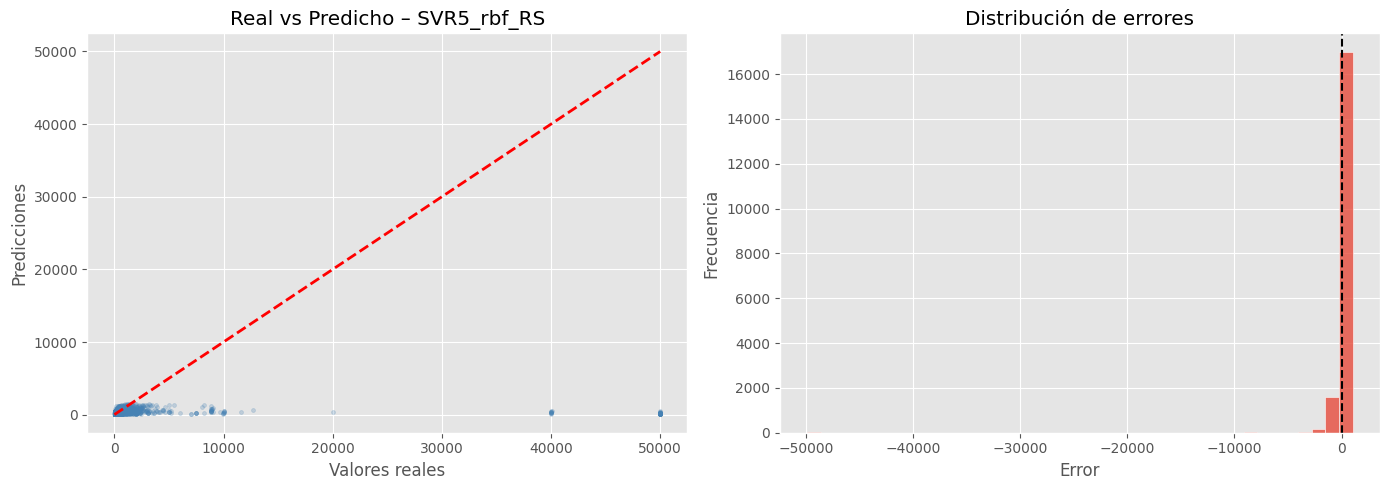

In [35]:
df_svr = pd.DataFrame([{
    'Modelo'     : n,
    'RMSE_Train' : rmse_train_svr[n],
    'RMSE_Test'  : rmse_test_svr[n],
    'R2_Train'   : r2_train_svr[n],
    'R2_Test'    : r2_test_svr[n],
    'Brecha_RMSE': round(rmse_test_svr[n] - rmse_train_svr[n], 4),
    'Tiempo_s'   : tiempos_svr[n],
} for n in modelos_svr])
print('=== Resumen SVR ===')
print(df_svr.to_string(index=False))

# Gráfico real vs predicho del mejor SVR
mejor_svr_n  = df_svr.loc[df_svr['RMSE_Test'].idxmin(), 'Modelo']
preds_svr_bst = modelos_svr[mejor_svr_n].predict(X_test_reg_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_reg, preds_svr_bst, alpha=0.25, s=8, color='steelblue')
lims = [min(y_test_reg.min(), preds_svr_bst.min()), max(y_test_reg.max(), preds_svr_bst.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Valores reales'); axes[0].set_ylabel('Predicciones')
axes[0].set_title(f'Real vs Predicho – {mejor_svr_n}')
errores_svr = preds_svr_bst - y_test_reg
axes[1].hist(errores_svr, bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Error'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de errores')
plt.tight_layout(); plt.show()

---
## 12. Comparación del SVR con modelos de regresión de labs anteriores

In [36]:
def eval_reg(nombre, modelo, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    elapsed = round(time.time() - t0, 2)
    preds_tr = modelo.predict(X_tr)
    preds_te = modelo.predict(X_te)
    return {
        'Modelo'     : nombre,
        'RMSE_Train' : round(np.sqrt(mean_squared_error(y_tr, preds_tr)), 4),
        'RMSE_Test'  : round(np.sqrt(mean_squared_error(y_te, preds_te)), 4),
        'MAE_Test'   : round(mean_absolute_error(y_te, preds_te), 4),
        'R2_Train'   : round(r2_score(y_tr, preds_tr), 4),
        'R2_Test'    : round(r2_score(y_te, preds_te), 4),
        'Tiempo_s'   : elapsed,
    }

reg_anteriores = [
    ('Reg_Lineal'  , LinearRegression(),
     X_train_reg.values, y_train_reg, X_test_reg.values, y_test_reg),
    ('Arbol_Reg'   , DecisionTreeRegressor(max_depth=5, random_state=SEED),
     X_train_reg.values, y_train_reg, X_test_reg.values, y_test_reg),
    ('RF_Reg'      , RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
     X_train_reg.values, y_train_reg, X_test_reg.values, y_test_reg),
    ('KNN_Reg_k5'  , KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
     X_train_reg_sc, y_train_reg, X_test_reg_sc, y_test_reg),
]

resultados_reg = []
for nombre, modelo, Xtr, ytr, Xte, yte in reg_anteriores:
    r = eval_reg(nombre, modelo, Xtr, ytr, Xte, yte)
    resultados_reg.append(r)
    print(f'{nombre}: RMSE_test={r["RMSE_Test"]}  R²={r["R2_Test"]}  {r["Tiempo_s"]}s')

# Agregar el mejor SVR
resultados_reg.append({
    'Modelo'     : f'SVR_best ({mejor_svr_n})',
    'RMSE_Train' : rmse_train_svr[mejor_svr_n],
    'RMSE_Test'  : rmse_test_svr[mejor_svr_n],
    'MAE_Test'   : round(mean_absolute_error(y_test_reg, preds_svr_bst), 4),
    'R2_Train'   : r2_train_svr[mejor_svr_n],
    'R2_Test'    : r2_test_svr[mejor_svr_n],
    'Tiempo_s'   : tiempos_svr[mejor_svr_n],
})

df_reg_comp = pd.DataFrame(resultados_reg).sort_values('RMSE_Test')
print('\n=== Comparación – todos los algoritmos de regresión ===')
print(df_reg_comp.to_string(index=False))

Reg_Lineal: RMSE_test=2173.6467  R²=0.0124  0.02s
Arbol_Reg: RMSE_test=1935.4844  R²=0.2169  0.05s
RF_Reg: RMSE_test=2020.9256  R²=0.1463  1.06s
KNN_Reg_k5: RMSE_test=2187.2346  R²=-0.0  0.13s

=== Comparación – todos los algoritmos de regresión ===
                Modelo  RMSE_Train  RMSE_Test  MAE_Test  R2_Train  R2_Test  Tiempo_s
             Arbol_Reg   2160.1199  1935.4844  305.0926    0.3318   0.2169      0.05
                RF_Reg   1543.6066  2020.9256  309.8680    0.6588   0.1463      1.06
            Reg_Lineal   2609.5917  2173.6467  421.3927    0.0249   0.0124      0.02
SVR_best (SVR5_rbf_RS)   2226.7339  2183.9891  233.2804    0.0059   0.0030     31.70
            KNN_Reg_k5   2105.2027  2187.2346  339.6027    0.3654  -0.0000      0.13


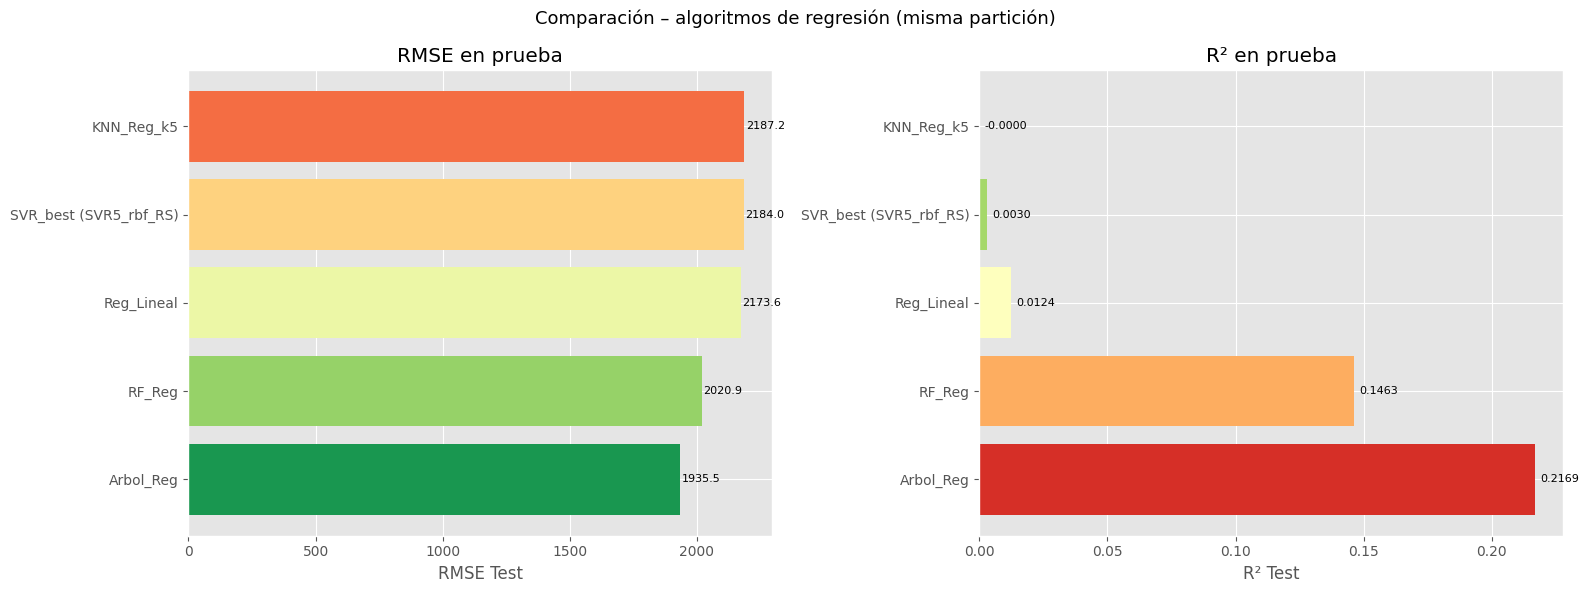

Mejor regresor (RMSE_Test más bajo): Arbol_Reg
Más rápido: Reg_Lineal


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

c = plt.cm.RdYlGn_r(np.linspace(0.1, 0.8, len(df_reg_comp)))
axes[0].barh(df_reg_comp['Modelo'], df_reg_comp['RMSE_Test'], color=c)
axes[0].set_xlabel('RMSE Test'); axes[0].set_title('RMSE en prueba')
for i, v in enumerate(df_reg_comp['RMSE_Test']):
    axes[0].text(v + 5, i, f'{v:.1f}', va='center', fontsize=8)

c2 = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(df_reg_comp)))
axes[1].barh(df_reg_comp['Modelo'], df_reg_comp['R2_Test'], color=c2)
axes[1].set_xlabel('R² Test'); axes[1].set_title('R² en prueba')
for i, v in enumerate(df_reg_comp['R2_Test']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Comparación – algoritmos de regresión (misma partición)', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Mejor regresor (RMSE_Test más bajo): {df_reg_comp.iloc[0]["Modelo"]}')
print(f'Más rápido: {df_reg_comp.loc[df_reg_comp["Tiempo_s"].idxmin(),"Modelo"]}')

In [38]:
# Tabla de sobreajuste – regresión
df_reg_comp['Brecha_RMSE'] = (df_reg_comp['RMSE_Test'] - df_reg_comp['RMSE_Train']).round(2)
df_reg_comp['Diagnóstico'] = df_reg_comp.apply(
    lambda r: 'Sobreajuste' if (r['R2_Train'] - r['R2_Test']) > 0.1
              else ('Desajuste' if r['R2_Test'] < 0.2 else 'Buen ajuste'), axis=1
)
print('=== Diagnóstico de sobreajuste – Regresión ===')
print(df_reg_comp[['Modelo','RMSE_Train','RMSE_Test','R2_Train','R2_Test',
                   'Brecha_RMSE','Diagnóstico']].to_string(index=False))

print("""
Métricas para detectar sobreajuste en regresión:
  1. RMSE_Test >> RMSE_Train → sobreajuste.
  2. R²_Train ≈ 1 pero R²_Test bajo → sobreajuste severo.
  3. MAE train vs test también refleja generalización.
""")

=== Diagnóstico de sobreajuste – Regresión ===
                Modelo  RMSE_Train  RMSE_Test  R2_Train  R2_Test  Brecha_RMSE Diagnóstico
             Arbol_Reg   2160.1199  1935.4844    0.3318   0.2169      -224.64 Sobreajuste
                RF_Reg   1543.6066  2020.9256    0.6588   0.1463       477.32 Sobreajuste
            Reg_Lineal   2609.5917  2173.6467    0.0249   0.0124      -435.95   Desajuste
SVR_best (SVR5_rbf_RS)   2226.7339  2183.9891    0.0059   0.0030       -42.74   Desajuste
            KNN_Reg_k5   2105.2027  2187.2346    0.3654  -0.0000        82.03 Sobreajuste

Métricas para detectar sobreajuste en regresión:
  1. RMSE_Test >> RMSE_Train → sobreajuste.
  2. R²_Train ≈ 1 pero R²_Test bajo → sobreajuste severo.
  3. MAE train vs test también refleja generalización.

